# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mkhlor006/Flyrank_internship_ML/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os
import sys
import subprocess
from pathlib import Path

REPO_DIR = Path("/content/Flyrank_internship_ML")
REPO_URL = "https://github.com/mkhlor006/Flyrank_internship_ML.git"

# Make sure the repository exists.
if not REPO_DIR.exists():
    subprocess.run(
        ["git", "clone", REPO_URL, str(REPO_DIR)],
        check=True
    )

os.chdir(REPO_DIR)

print("Working directory:", Path.cwd())

# The processed feature vector is generated from the raw starter dataset.
feature_path = Path("data/processed/refresh_feature_vector.csv")

if not feature_path.exists():
    print("Feature vector not found. Generating it...")
    subprocess.run(
        [sys.executable, "scripts/01_prepare_features.py"],
        check=True
    )

df = __import__("pandas").read_csv(feature_path)

print("\nFeature vector loaded.")
print("Shape:", df.shape)
print("Columns:", len(df.columns))

Working directory: /content/Flyrank_internship_ML
Feature vector not found. Generating it...

Feature vector loaded.
Shape: (30000, 52)
Columns: 52


## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

### Distribution notes

I first inspect the distributions of the fields used in the signal tests. Traffic and performance measures such as impressions and sessions are expected to be heavy-tailed, so I report summary statistics and also inspect log-transformed values. The analysis also treats `avg_position = 0` as no measured search position rather than as an actual ranking position.

The main fields tested below are historical impressions, average search position and days since the last update. I also inspect content length because it is used by one of the refresh flags.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

distribution_fields = [
    "impressions_90d",
    "avg_position",
    "days_since_last_update",
    "word_count",
    "sessions_90d"
]

distribution_summary = df[distribution_fields].describe(
    percentiles=[0.50, 0.90, 0.95, 0.99]
).T

distribution_summary["zero_count"] = [
    int((df[col] == 0).sum())
    for col in distribution_fields
]

display(distribution_summary)

print("\nAverage-position rows with no measured position (0):",
      int((df["avg_position"] == 0).sum()))

print("\nKey distribution observations:")
print(
    "Impressions and sessions show strong right-skew/heavy-tail behaviour, "
    "so log-transformed views are useful for inspection."
)

,count,mean,std,min,50%,90%,95%,99%,max,zero_count
impressions_90d,30000.0,5200.366300,16838.019547,1.0,731.0,12136.4,22996.50,73505.830,517715.0,0
avg_position,30000.0,16.342380,15.216790,0.0,10.8,36.8,48.20,69.901,245.0,1205
days_since_last_update,30000.0,46.098300,42.078709,1.0,20.0,104.0,104.00,106.000,373.0,0
word_count,30000.0,2310.205433,1846.788556,0.0,2605.0,4719.2,5876.15,7090.080,9546.0,7699
sessions_90d,30000.0,37.066633,107.069131,1.0,7.0,88.0,166.00,451.010,4345.0,0



Average-position rows with no measured position (0): 1205

Key distribution observations:
Impressions and sessions show strong right-skew/heavy-tail behaviour, so log-transformed views are useful for inspection.


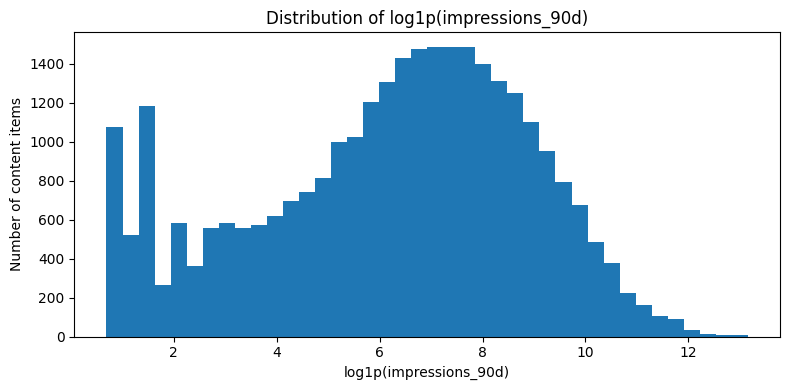

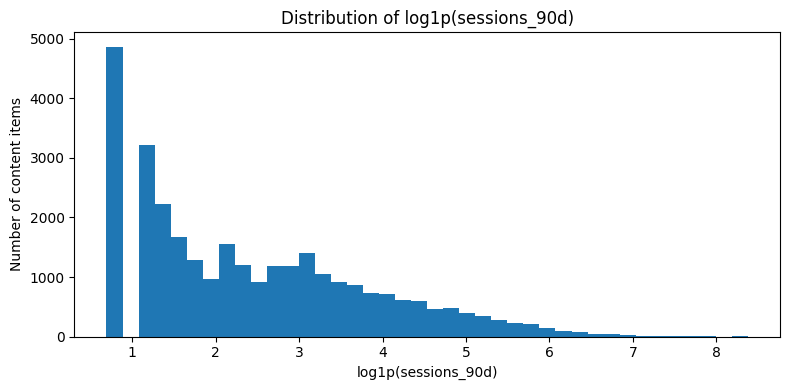

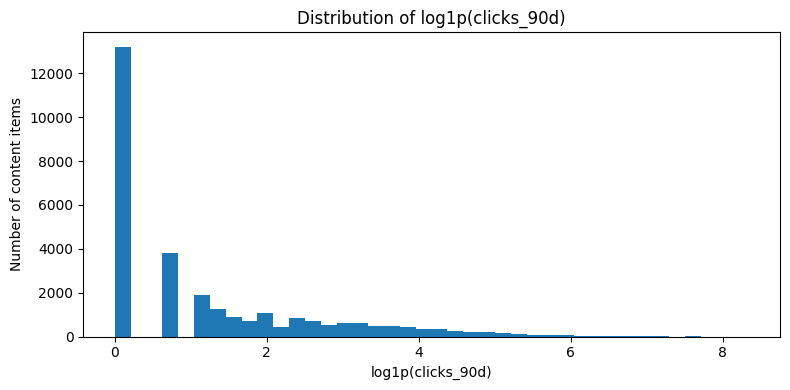

In [3]:
heavy_tail_fields = [
    "impressions_90d",
    "sessions_90d",
    "clicks_90d"
]

for col in heavy_tail_fields:
    plt.figure(figsize=(8, 4))
    plt.hist(
        np.log1p(df[col]),
        bins=40
    )
    plt.xlabel(f"log1p({col})")
    plt.ylabel("Number of content items")
    plt.title(f"Distribution of log1p({col})")
    plt.tight_layout()
    plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

### Signal 1 — Historical visibility

**Claim:** Higher historical search visibility is associated with a higher decline rate.

**Test:** Compare the observed decline-label rate across historical impression tiers. Each bucket reports its sample size (`n`) and decline rate.

### Signal 2 — Search position

**Claim:** Worse search position, represented by a larger average-position value, is associated with a higher decline rate.

**Test:** Compare the observed decline-label rate across search-position tiers. Rows with `avg_position = 0` are excluded because zero represents no measured position.

### Signal 3 — Freshness

**Claim:** A longer time since the last update is associated with a higher decline rate.

**Test:** Compare the observed decline-label rate across `days_since_last_update` tiers.

For all three tests, a bucket with fewer than 50 observations is not used to support a final verdict. A practical 5-percentage-point end-to-end difference is used as the threshold for calling a directional difference meaningful. A non-monotonic but materially different pattern is reported as MIXED rather than forced into a directional conclusion.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
MIN_BUCKET_N = 50
MEANINGFUL_GAP = 0.05  # 5 percentage points


def make_signal_table(data, column, bins, labels, include_right=True):
    temp = data.copy()

    temp["bucket"] = pd.cut(
        temp[column],
        bins=bins,
        labels=labels,
        include_lowest=True,
        right=include_right
    )

    temp = temp.dropna(subset=["bucket"])

    result = (
        temp.groupby("bucket", observed=False)["is_declining_label"]
        .agg(
            n="size",
            declines="sum",
            decline_rate="mean"
        )
        .reset_index()
    )

    return result


def signal_verdict(
    table,
    direction="increasing",
    min_n=MIN_BUCKET_N,
    meaningful_gap=MEANINGFUL_GAP
):
    valid = table[table["n"] >= min_n].copy()

    if len(valid) < 2:
        return "INSUFFICIENT DATA"

    rates = valid["decline_rate"].to_numpy()

    first_rate = rates[0]
    last_rate = rates[-1]
    gap = last_rate - first_rate

    if abs(gap) < meaningful_gap:
        if (rates.max() - rates.min()) >= meaningful_gap:
            return "MIXED"
        return "FALSE"

    diffs = np.diff(rates)

    increasing = np.all(diffs >= -0.01)
    decreasing = np.all(diffs <= 0.01)

    if direction == "increasing":
        if increasing:
            return "CONFIRMED"
        if decreasing:
            return "OPPOSITE"
        return "MIXED"

    if direction == "decreasing":
        if decreasing:
            return "CONFIRMED"
        if increasing:
            return "OPPOSITE"
        return "MIXED"

    return "MIXED"

In [5]:
# SIGNAL 1: historical impressions

impression_bins = [
    0,
    100,
    500,
    5000,
    np.inf
]

impression_labels = [
    "1-99",
    "100-499",
    "500-4,999",
    "5,000+"
]

signal1 = make_signal_table(
    df[df["impressions_90d"] > 0],
    "impressions_90d",
    impression_bins,
    impression_labels
)

signal1["decline_rate_pct"] = signal1["decline_rate"] * 100

display(signal1)

signal1_verdict = signal_verdict(
    signal1,
    direction="increasing"
)

print("Signal 1 verdict:", signal1_verdict)

,bucket,n,declines,decline_rate,decline_rate_pct
0,1-99,8006,3116,0.389208,38.920809
1,100-499,5279,3190,0.604281,60.428111
2,"500-4,999",10565,6594,0.624136,62.413630
3,"5,000+",6150,3362,0.546667,54.666667


Signal 1 verdict: MIXED


In [6]:
# SIGNAL 2: search position

position_data = df[
    (df["avg_position"] > 0)
].copy()

position_bins = [
    0,
    10,
    20,
    50,
    np.inf
]

position_labels = [
    "1-10",
    "11-20",
    "21-50",
    "51+"
]

signal2 = make_signal_table(
    position_data,
    "avg_position",
    position_bins,
    position_labels
)

signal2["decline_rate_pct"] = signal2["decline_rate"] * 100

display(signal2)

signal2_verdict = signal_verdict(
    signal2,
    direction="increasing"
)

print("Signal 2 verdict:", signal2_verdict)

,bucket,n,declines,decline_rate,decline_rate_pct
0,1-10,12983,7311,0.563121,56.312100
1,11-20,7273,4433,0.609515,60.951464
2,21-50,7225,4059,0.561799,56.179931
3,51+,1314,451,0.343227,34.322679


Signal 2 verdict: MIXED


In [7]:
# SIGNAL 3: days since last update

freshness_bins = [
    -np.inf,
    89,
    179,
    364,
    np.inf
]

freshness_labels = [
    "<90 days",
    "90-179 days",
    "180-364 days",
    "365+ days"
]

signal3 = make_signal_table(
    df,
    "days_since_last_update",
    freshness_bins,
    freshness_labels
)

signal3["decline_rate_pct"] = signal3["decline_rate"] * 100

display(signal3)

signal3_verdict = signal_verdict(
    signal3,
    direction="increasing"
)

print("Signal 3 verdict:", signal3_verdict)

,bucket,n,declines,decline_rate,decline_rate_pct
0,<90 days,20655,10576,0.512031,51.203099
1,90-179 days,9171,5604,0.611057,61.105659
2,180-364 days,169,79,0.467456,46.745562
3,365+ days,5,3,0.600000,60.000000


Signal 3 verdict: MIXED


In [8]:
verdict_summary = pd.DataFrame({
    "signal": [
        "Historical visibility",
        "Search position",
        "Freshness"
    ],
    "verdict": [
        signal1_verdict,
        signal2_verdict,
        signal3_verdict
    ]
})

display(verdict_summary)

,signal,verdict
0,Historical visibility,MIXED
1,Search position,MIXED
2,Freshness,MIXED


### Rerun check

To test whether the search-position pattern is sensitive to the definition of measurable opportunity, I rerun Signal 2 on the subset where `measurable_opportunity = 1`. This provides a different slice of the same dataset rather than relying on only one overall result.

In [9]:
rerun_data = df[
    (df["measurable_opportunity"] == 1) &
    (df["avg_position"] > 0)
].copy()

rerun_signal2 = make_signal_table(
    rerun_data,
    "avg_position",
    position_bins,
    position_labels
)

rerun_signal2["decline_rate_pct"] = (
    rerun_signal2["decline_rate"] * 100
)

display(rerun_signal2)

rerun_signal2_verdict = signal_verdict(
    rerun_signal2,
    direction="increasing"
)

print("Signal 2 rerun verdict:", rerun_signal2_verdict)
print("Rows in rerun slice:", len(rerun_data))

,bucket,n,declines,decline_rate,decline_rate_pct
0,1-10,9215,5668,0.615084,61.508410
1,11-20,5876,3679,0.626106,62.610619
2,21-50,6037,3526,0.584065,58.406493
3,51+,878,279,0.317768,31.776765


Signal 2 rerun verdict: MIXED
Rows in rerun slice: 22006


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

### Flag-linked test — `low_ctr_visible_page`

**Claim:** Among pages with meaningful visibility and a search position in the top 20, pages with CTR below 0.5 are more likely to have the declining label.

This test mirrors the real baseline flag rather than inventing a new rule. I compare the decline rate for pages that satisfy the flag condition with pages in the same visible/top-20 population that do not satisfy the low-CTR condition.

The flag should be treated as a prioritisation signal rather than proof that refreshing the page will improve performance.

In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Recreate the baseline's visible/top-20 population.

eligible = df[
    (df["impressions_90d"] >= 500) &
    (df["avg_position"] > 0) &
    (df["avg_position"] <= 20)
].copy()

eligible["low_ctr_flag"] = (
    eligible["ctr"] < 0.5
).astype(int)

flag_test = (
    eligible.groupby("low_ctr_flag")["is_declining_label"]
    .agg(
        n="size",
        declines="sum",
        decline_rate="mean"
    )
    .reset_index()
)

flag_test["group"] = flag_test["low_ctr_flag"].map({
    0: "Visible/top-20 but CTR >= 0.5",
    1: "low_ctr_visible_page flag"
})

flag_test["decline_rate_pct"] = (
    flag_test["decline_rate"] * 100
)

display(
    flag_test[
        [
            "group",
            "n",
            "declines",
            "decline_rate",
            "decline_rate_pct"
        ]
    ]
)

# Extract rates.
flagged = flag_test[
    flag_test["low_ctr_flag"] == 1
]

unflagged = flag_test[
    flag_test["low_ctr_flag"] == 0
]

if len(flagged) == 1 and len(unflagged) == 1:
    flagged_rate = float(flagged["decline_rate"].iloc[0])
    unflagged_rate = float(unflagged["decline_rate"].iloc[0])

    gap = flagged_rate - unflagged_rate

    if (
        flagged["n"].iloc[0] >= MIN_BUCKET_N
        and unflagged["n"].iloc[0] >= MIN_BUCKET_N
    ):
        if gap >= MEANINGFUL_GAP:
            flag_verdict = "CONFIRMED"
        elif gap <= -MEANINGFUL_GAP:
            flag_verdict = "OPPOSITE"
        else:
            flag_verdict = "FALSE"
    else:
        flag_verdict = "INSUFFICIENT DATA"

    print("Flagged decline rate:", round(flagged_rate * 100, 2), "%")
    print("Unflagged decline rate:", round(unflagged_rate * 100, 2), "%")
    print("Difference:", round(gap * 100, 2), "percentage points")
    print("Flag-linked verdict:", flag_verdict)
else:
    print("Could not calculate the flag comparison.")

,group,n,declines,decline_rate,decline_rate_pct
0,Visible/top-20 but CTR >= 0.5,2264,1076,0.475265,47.526502
1,low_ctr_visible_page flag,9759,6120,0.627113,62.711343


Flagged decline rate: 62.71 %
Unflagged decline rate: 47.53 %
Difference: 15.18 percentage points
Flag-linked verdict: CONFIRMED


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

The signal audit shows which historical signals provide useful directional evidence and which should be treated more cautiously. A content team should use supported signals as prioritisation inputs and combine them with page-level review rather than treating any individual flag as an automatic refresh decision.

The audit also shows why sample size, bucket structure and validation across different slices matter when deciding whether a signal is reliable enough to use operationally.

In [11]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
print("Signal 1:", signal1_verdict)
print("Signal 2:", signal2_verdict)
print("Signal 3:", signal3_verdict)
print("Signal 2 rerun:", rerun_signal2_verdict)
print("Flag-linked test:", flag_verdict)

print("\nML-06 signal audit completed.")

Signal 1: MIXED
Signal 2: MIXED
Signal 3: MIXED
Signal 2 rerun: MIXED
Flag-linked test: CONFIRMED

ML-06 signal audit completed.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.